In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

In [2]:
sys.path.append(os.path.abspath(".."))

from lago_data_model.utils import plot_readings
from lago_data_model.data_utils import extract_pulses

# Exploratory Data Analysis

In [3]:
data = pd.read_parquet("../data/20210518_142318.parquet")

In [4]:
data.head(5)

,TBP,readings
0,51491,"[198.0, 197.0, 197.0, 196.0, 197.0, 196.0, 197..."
1,168153,"[195.0, 194.0, 194.0, 194.0, 194.0, 194.0, 192..."
2,2613,"[197.0, 197.0, 198.0, 196.0, 196.0, 194.0, 194..."
3,111025,"[195.0, 194.0, 194.0, 192.0, 194.0, 190.0, 185..."
4,10736,"[197.0, 196.0, 197.0, 196.0, 197.0, 196.0, 193..."


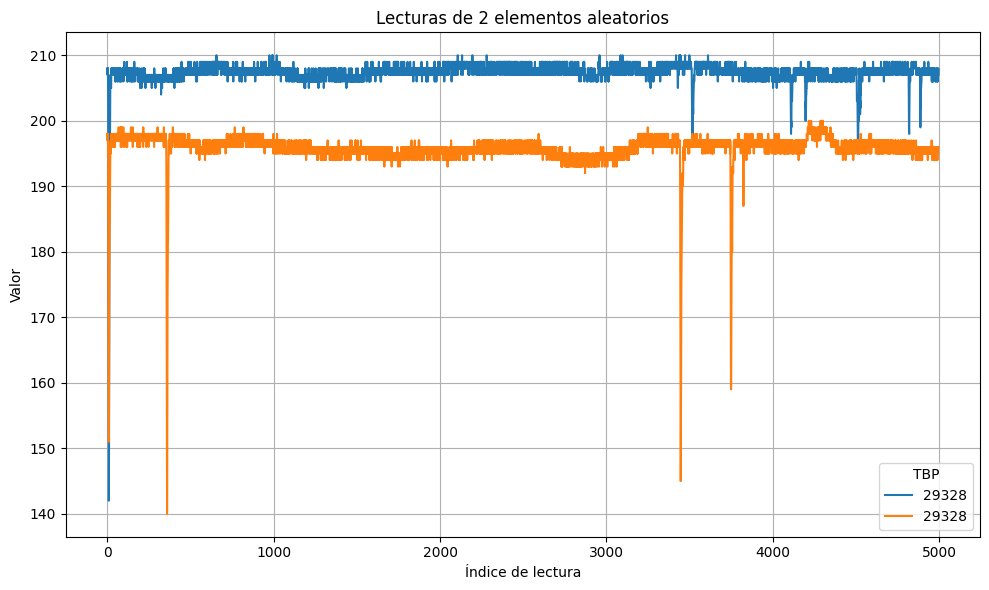

In [5]:
plot_readings(data[data['TBP']==29328], 2, legend=True)

## Detect Pulse

In [29]:
pulse_read = data[data['TBP']==29328]['readings'].iloc[0][:450]

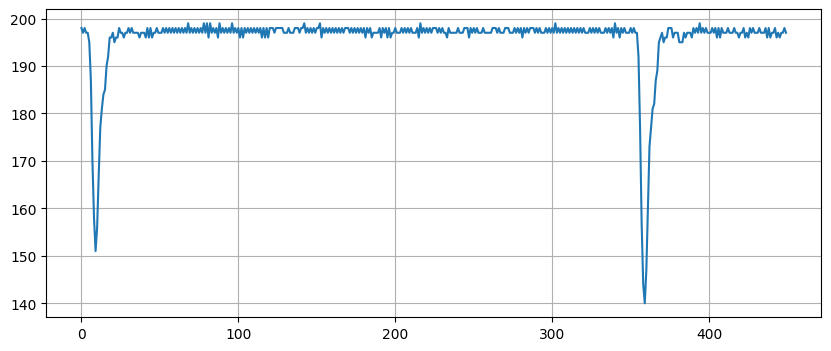

In [30]:
plt.figure(figsize=(10,4))
sns.lineplot(pulse_read)
plt.grid(True)

`nsigma * MAD` es un criterio estadístico para fijar el **umbral de detección** de pulsos:

- **MAD (Median Absolute Deviation)**:  
  Es una medida robusta de dispersión (similar a la desviación estándar, pero menos sensible a valores atípicos).  
  $ 
  MAD = \text{mediana}(|x_i - \text{mediana}(x)|)
  $

- **nsigma**:  
  Es un factor de escala. Por ejemplo, si `nsigma = 3`, se interpreta como "3 desviaciones típicas robustas".

- **nsigma * MAD**:  
  Indica cuán lejos del valor típico (mediana) debe estar una muestra para ser considerada parte de un pulso.  
  En el código, el umbral era:
  $
  \text{umbral} = \text{mediana}(x) - nsigma \cdot MAD
  $

In [31]:
df_pulses = extract_pulses(
    pulse_read, 
    nsigma_threshold=3.0, crossback_nsigma=1.0, 
    min_len=3, baseline_win=25
)

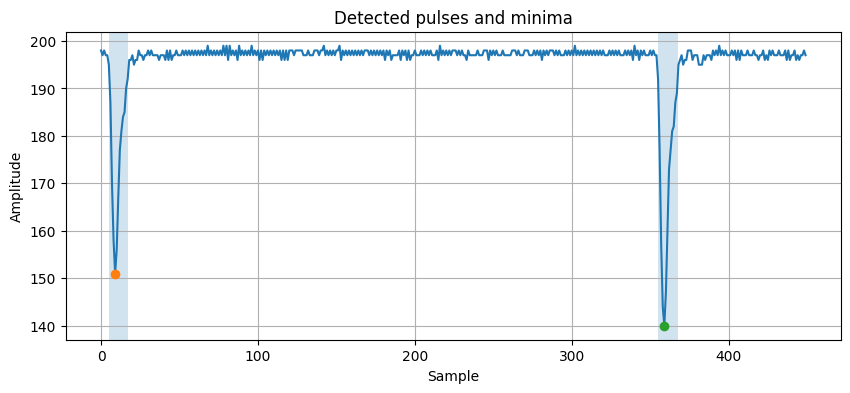

In [32]:
# Plot with detected regions and key points
plt.figure(figsize=(10,4))
plt.plot(pulse_read)
for _, r in df_pulses.iterrows():
    i0, i1 = int(r.start_idx), int(r.end_idx)
    kmin = int(r.min_idx)
    plt.axvspan(i0, i1, alpha=0.2)
    plt.plot(kmin, pulse_read[kmin], 'o')
plt.title("Detected pulses and minima")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [10]:
df_pulses

,start_idx,min_idx,end_idx,min_value,baseline_local,depth,width_samples,area_under_pulse,fwhm_samples,rise_time,recovery_time,snr_depth_over_mad
0,5,9,17,151.0,197.0,46.0,13,268.0,5,4,8,46.0
1,355,359,368,140.0,197.0,57.0,14,357.0,5,4,9,57.0


In [25]:
pulse_read = data.sample(1)['readings'].iloc[0]

In [26]:
df_pulses = extract_pulses(
    pulse_read, 
    nsigma_threshold=3.0, crossback_nsigma=1.0, 
    min_len=3, baseline_win=25
)

In [27]:
df_pulses

,start_idx,min_idx,end_idx,min_value,baseline_local,depth,width_samples,area_under_pulse,fwhm_samples,rise_time,recovery_time,snr_depth_over_mad
0,5,11,25,128.0,200.5,72.5,21,485.5,5,6,14,72.5
1,5,11,25,128.0,200.5,72.5,21,485.5,5,6,14,72.5
2,1303,1306,1319,174.0,201.0,27.0,17,164.0,4,3,13,27.0
3,1321,1323,1325,198.0,200.0,2.0,5,7.0,5,2,2,2.0
4,2455,2455,2461,197.0,202.5,5.5,7,29.5,5,0,6,5.5


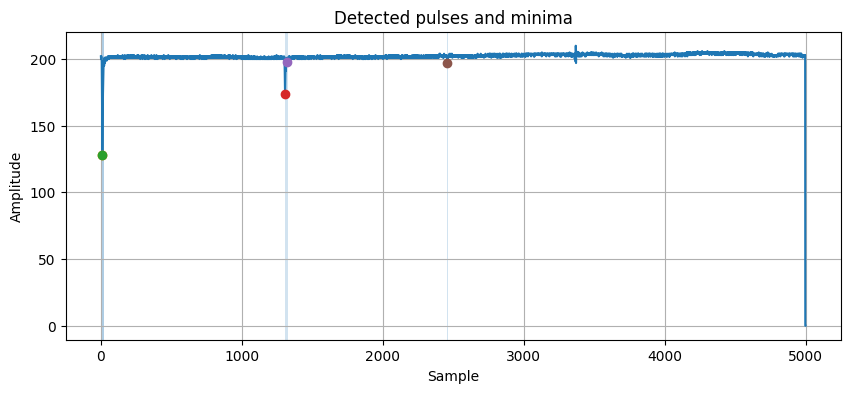

In [28]:
plt.figure(figsize=(10,4))
plt.plot(pulse_read)
for _, r in df_pulses.iterrows():
    i0, i1 = int(r.start_idx), int(r.end_idx)
    kmin = int(r.min_idx)
    plt.axvspan(i0, i1, alpha=0.2)
    plt.plot(kmin, pulse_read[kmin], 'o')
plt.title("Detected pulses and minima")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()